In [3]:
import os, json

os.chdir(r'C:\Users\zkx14\Desktop\testing')
print('Working directory:', os.getcwd())

with open('splits.json') as f:
    splits = json.load(f)

img_paths_all  = splits['images']
mask_paths_all = splits['masks']

print(f'Loaded {len(img_paths_all)} image-mask pairs')

Working directory: C:\Users\zkx14\Desktop\testing
Loaded 232 image-mask pairs


Train: 185 | Val: 47
Using: NVIDIA RTX 2000 Ada Generation


C:\Users\zkx14\AppData\Local\Temp\ipykernel_21296\3980937095.py:102: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler()
C:\Users\zkx14\AppData\Local\Temp\ipykernel_21296\3980937095.py:121: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\zkx14\AppData\Local\Temp\ipykernel_21296\3980937095.py:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 01/50 | Train Loss: 0.4808 | Val Loss: 0.3463
           ✓ Best model saved (val loss: 0.3463)
Epoch 02/50 | Train Loss: 0.2208 | Val Loss: 0.1991
           ✓ Best model saved (val loss: 0.1991)
Epoch 03/50 | Train Loss: 0.1474 | Val Loss: 0.1495
           ✓ Best model saved (val loss: 0.1495)
Epoch 04/50 | Train Loss: 0.1131 | Val Loss: 0.1187
           ✓ Best model saved (val loss: 0.1187)
Epoch 05/50 | Train Loss: 0.0930 | Val Loss: 0.0977
           ✓ Best model saved (val loss: 0.0977)
Epoch 06/50 | Train Loss: 0.0809 | Val Loss: 0.0824
           ✓ Best model saved (val loss: 0.0824)
Epoch 07/50 | Train Loss: 0.0734 | Val Loss: 0.0766
           ✓ Best model saved (val loss: 0.0766)
Epoch 08/50 | Train Loss: 0.0662 | Val Loss: 0.0693
           ✓ Best model saved (val loss: 0.0693)
Epoch 09/50 | Train Loss: 0.0636 | Val Loss: 0.0686
           ✓ Best model saved (val loss: 0.0686)
Epoch 10/50 | Train Loss: 0.0627 | Val Loss: 0.0665
           ✓ Best model saved (val loss

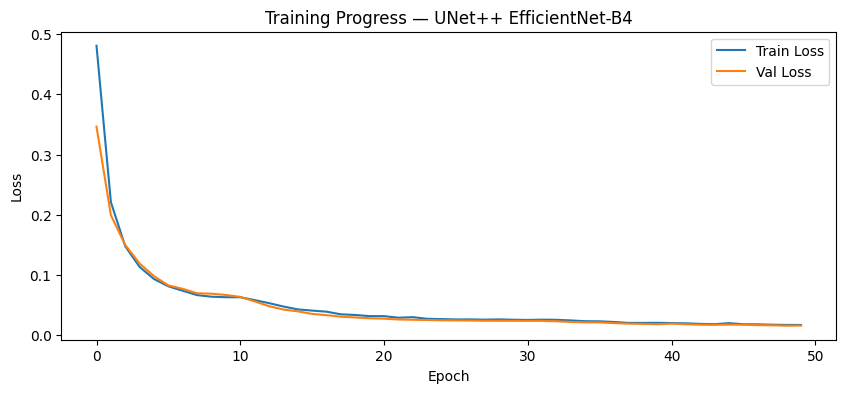


Done! Best val loss: 0.0154
Model  -> models/unet++_efficientb4.pth


In [5]:
# Dental X-ray mandible segmentation
# UNet++ with EfficientNet-B4 backbone + combined Dice-BCE loss
#
# UNet++ difference from plain UNet:
# - dense skip connections between encoder and decoder
# - re-designed decoder with nested layers
# - captures finer detail at every scale
# - typically +2-4% Dice over plain UNet on same encoder

import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split
import cv2
import numpy as np
import matplotlib.pyplot as plt


# Custom Dataset
class DentalDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.transform  = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img  = cv2.imread(str(self.img_paths[idx]))
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(self.mask_paths[idx]), 0)
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img, mask = aug['image'], aug['mask']

        return img, mask.unsqueeze(0)


# Transforms
train_transform = A.Compose([
    A.Resize(512, 1024),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussianBlur(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.4),
    A.CLAHE(clip_limit=4.0, p=0.3),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(512, 1024),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])


# Train / Validation Split
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    img_paths_all, mask_paths_all,
    test_size=0.2, random_state=42          # same seed = same split as all other models
)
print(f'Train: {len(train_imgs)} | Val: {len(val_imgs)}')


# DataLoaders — batch size 4 for UNet++ with EfficientNet-B4
train_ds = DentalDataset(train_imgs, train_masks, train_transform)
val_ds   = DentalDataset(val_imgs,   val_masks,   val_transform)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=0, pin_memory=True)


# Model — UnetPlusPlus instead of Unet, everything else same
device = torch.device('cuda')
print(f'Using: {torch.cuda.get_device_name(0)}')

model = smp.UnetPlusPlus(
    encoder_name='efficientnet-b4',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation=None
).to(device)


# Combined Dice + BCE loss
dice_loss = smp.losses.DiceLoss(mode='binary', from_logits=True)
bce_loss  = smp.losses.SoftBCEWithLogitsLoss()

def loss_fn(preds, masks):
    return 0.5 * dice_loss(preds, masks) + 0.5 * bce_loss(preds, masks)


# Cosine annealing scheduler
scaler    = torch.cuda.amp.GradScaler()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)


# Training loop
best_val_loss = float('inf')
train_losses  = []
val_losses    = []

for epoch in range(50):

    # Train
    model.train()
    train_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        with torch.cuda.amp.autocast():
            preds = model(imgs)
            loss  = loss_fn(preds, masks)
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()

    # Validate
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            with torch.cuda.amp.autocast():
                preds     = model(imgs)
                val_loss += loss_fn(preds, masks).item()

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(epoch)

    print(f'Epoch {epoch+1:02d}/50 | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'models/unet++_efficientb4.pth')
        print(f'           ✓ Best model saved (val loss: {best_val_loss:.4f})')


# Loss curve
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress — UNet++ EfficientNet-B4')
plt.legend()
plt.show()

print(f'\nDone! Best val loss: {best_val_loss:.4f}')
print('Model  -> models/unet++_efficientb4.pth')